In [3]:
import pandas as pd

df = pd.read_csv('Amazon.csv')
df.head()

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43


In [4]:
display(df.info())
display(df.isnull().sum())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         100 non-null    object
 1   Velocidad Entrega  100 non-null    int64 
 2   Precio             100 non-null    int64 
 3   Durabilidad        100 non-null    int64 
 4   Imagen Producto    100 non-null    int64 
 5   Valor Educativo    100 non-null    int64 
 6   Servicio Retorno   100 non-null    int64 
 7   Tamano Paquete     100 non-null    int64 
 8   Calidad Producto   100 non-null    int64 
 9   Numero Estrellas   100 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 7.9+ KB


None

Unnamed: 0           0
Velocidad Entrega    0
Precio               0
Durabilidad          0
Imagen Producto      0
Valor Educativo      0
Servicio Retorno     0
Tamano Paquete       0
Calidad Producto     0
Numero Estrellas     0
dtype: int64

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,91.240000,58.350000,238.100000,143.870000,25.560000,23.860000,155.770000,129.200000,28.220000
std,95.021223,65.009615,188.035699,121.765519,11.288074,9.631619,163.857653,110.628234,11.720292
min,0.000000,1.000000,3.000000,2.000000,2.000000,3.000000,3.000000,2.000000,1.000000
25%,15.000000,9.000000,41.000000,25.000000,21.000000,19.000000,32.500000,24.000000,22.750000
50%,26.000000,22.500000,295.000000,150.000000,27.500000,25.000000,42.000000,165.000000,30.000000
75%,167.500000,95.000000,417.500000,245.000000,34.000000,28.000000,320.000000,227.500000,36.500000
max,305.000000,225.000000,495.000000,355.000000,46.000000,46.000000,495.000000,335.000000,48.000000


In [5]:
df = df.set_index('Unnamed: 0')
features = df.columns
X = df[features].values
display(df.head())
display(X[:5])

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
Unnamed: 0,,,,,,,,,
Adam,205,3,345,235,24,23,26,21,17
Anna,9,15,315,33,25,4,42,215,28
Bernard,17,26,285,3,43,27,41,26,33
Edward,135,5,355,295,18,23,39,195,17
Emilia,3,45,48,39,34,46,225,34,43


array([[205,   3, 345, 235,  24,  23,  26,  21,  17],
       [  9,  15, 315,  33,  25,   4,  42, 215,  28],
       [ 17,  26, 285,   3,  43,  27,  41,  26,  33],
       [135,   5, 355, 295,  18,  23,  39, 195,  17],
       [  3,  45,  48,  39,  34,  46, 225,  34,  43]])

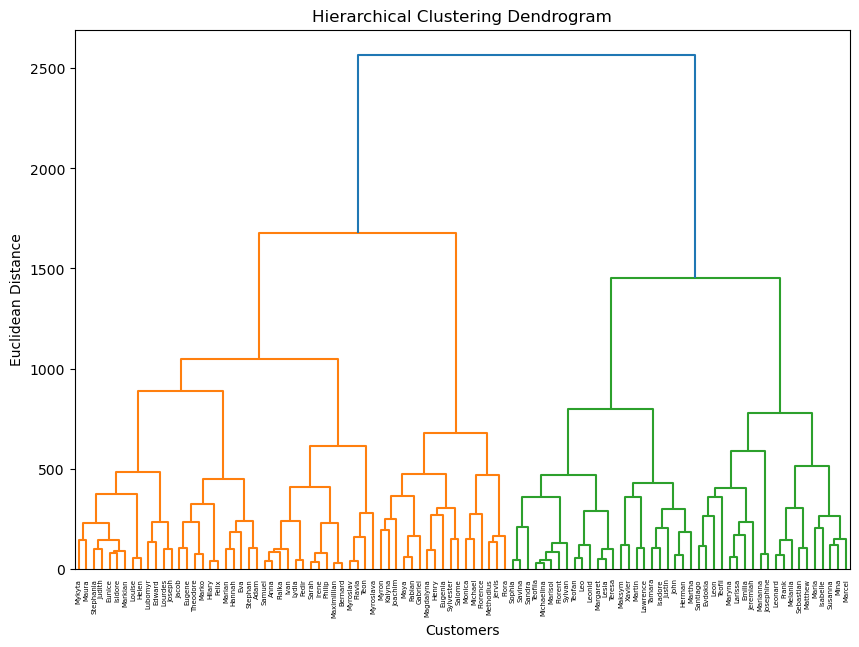

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

linked = linkage(X, method='ward', metric='euclidean')

plt.figure(figsize=(10, 7))
dendrogram(linked,
            orientation='top',
            labels=df.index.tolist(),
            distance_sort='descending',
            show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

In [7]:
# Basándonos en el dendrograma, elijamos 3 clústeres.
n_clusters = 3
cluster = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
df['cluster'] = cluster.fit_predict(X)
display(df.head())
display(df['cluster'].value_counts())

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,cluster
Unnamed: 0,,,,,,,,,,
Adam,205,3,345,235,24,23,26,21,17,1
Anna,9,15,315,33,25,4,42,215,28,1
Bernard,17,26,285,3,43,27,41,26,33,1
Edward,135,5,355,295,18,23,39,195,17,1
Emilia,3,45,48,39,34,46,225,34,43,0


cluster
0    44
1    39
2    17
Name: count, dtype: int64

In [8]:
cluster_means = df.groupby('cluster').mean()
display(cluster_means)

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
cluster,,,,,,,,,
0,85.454545,68.090909,35.909091,129.409091,24.909091,23.522727,178.613636,118.431818,27.909091
1,109.615385,44.333333,400.384615,177.820513,27.307692,23.435897,37.512821,148.666667,28.102564
2,64.058824,65.294118,389.117647,103.411765,23.235294,25.705882,367.941176,112.411765,29.294118


In [12]:
# Obtenemos el clúster al que pertenece cada persona
salome_cluster = df.loc['Salome', 'cluster']
stephania_cluster = df.loc['Stephania', 'cluster']
lydia_cluster = df.loc['Lydia', 'cluster']

print(f"Salome's cluster: {salome_cluster}")
print(f"Stephania's cluster: {stephania_cluster}")
print(f"Lydia's cluster: {lydia_cluster}")

Salome's cluster: 2
Stephania's cluster: 1
Lydia's cluster: 1


In [13]:
display(df.index.tolist())

['Adam',
 'Anna',
 'Bernard',
 'Edward',
 'Emilia',
 'Fabian',
 'Philip',
 'Frank',
 'Xavier',
 'Gabriel',
 'Marisol',
 'Henry',
 'Irene',
 'Isabelle',
 'Isidore',
 'Joseph',
 'Eugene',
 'Eugenia',
 'Eunice',
 'Eva',
 'Evdokia',
 'Fedir',
 'Felix',
 'Fialka',
 'Flavia',
 'Flora',
 'Florent',
 'Florence',
 'Hannah',
 'Helen',
 'Herman',
 'Hilary',
 'Lourdes',
 'Isadore',
 'Ivan',
 'Jacob',
 'Jeremiah',
 'Jervis',
 'Joachim',
 'John',
 'Santiago',
 'Josephine',
 'Judith',
 'Justin',
 'Kalyna',
 'Larissa',
 'Lawrence',
 'Leon',
 'Leonard',
 'Leonid',
 'Lesia',
 'Leo',
 'Louise',
 'Lubomyr',
 'Lydia',
 'Magdalyna',
 'Maksym',
 'Marcel',
 'Margaret',
 'Maria',
 'Marian',
 'Marianna',
 'Markian',
 'Marko',
 'Martha',
 'Martin',
 'Maryna',
 'Matthew',
 'Maura',
 'Maya',
 'Maximillian',
 'Melania',
 'Methodius',
 'Michael',
 'Michaelina',
 'Mina',
 'Monica',
 'Mykyta',
 'Myron',
 'Myroslav',
 'Myroslava',
 'Salome',
 'Samuel',
 'Sandra',
 'Sarah',
 'Savina',
 'Sebastian',
 'Sophia',
 'Stephan'

In [14]:
# Calcular el promedio general de cada producto
overall_average = df.drop('cluster', axis=1).mean()

# Lista de clientes a los que se les harán recomendaciones
customers_of_interest = ['Salome', 'Stephania', 'Lydia']
recommendations = {}

for customer_name in customers_of_interest:
    # Obtener el clúster del cliente actual
    customer_cluster = df.loc[customer_name, 'cluster']

    # Filtrar los clientes que están en el mismo clúster, excluyendo al cliente de interés
    similar_customers_df = df[(df['cluster'] == customer_cluster) & (df.index != customer_name)]

    # Obtener los nombres de los clientes similares
    similar_customer_names = similar_customers_df.index.tolist()

    # Calcular el promedio de consumo de productos para el grupo de clientes similares
    similar_customers_average = similar_customers_df.drop('cluster', axis=1).mean()

    # Identificar los productos donde los clientes similares tienen un promedio mayor al promedio general
    recommended_products = similar_customers_average[similar_customers_average > overall_average].index.tolist()

    # Guardar los resultados
    recommendations[customer_name] = {
        'cluster': customer_cluster,
        'similar_customers': similar_customer_names,
        'recommended_products': recommended_products
    }

# Imprimir las recomendaciones para cada cliente
for customer, data in recommendations.items():
    print(f"Recomendaciones para {customer} (Clúster {data['cluster']}):")
    print(f"  Clientes similares en el mismo clúster: {', '.join(data['similar_customers'])}")
    print(f"  Productos recomendados según las preferencias del clúster: {', '.join(data['recommended_products'])}")
    print("-" * 30)


Recomendaciones para Salome (Clúster 2):
  Clientes similares en el mismo clúster: Fabian, Gabriel, Henry, Eugenia, Flora, Florence, Jervis, Joachim, Kalyna, Magdalyna, Maya, Methodius, Michael, Monica, Myron, Sylvester
  Productos recomendados según las preferencias del clúster: Precio, Durabilidad, Servicio Retorno, Tamano Paquete, Numero Estrellas
------------------------------
Recomendaciones para Stephania (Clúster 1):
  Clientes similares en el mismo clúster: Adam, Anna, Bernard, Edward, Philip, Irene, Isidore, Joseph, Eugene, Eunice, Eva, Fedir, Felix, Fialka, Flavia, Hannah, Helen, Hilary, Lourdes, Ivan, Jacob, Judith, Louise, Lubomyr, Lydia, Marian, Markian, Marko, Maura, Maximillian, Mykyta, Myroslav, Myroslava, Samuel, Sarah, Stephan, Theodore, Teon
  Productos recomendados según las preferencias del clúster: Velocidad Entrega, Durabilidad, Imagen Producto, Valor Educativo, Servicio Retorno, Calidad Producto
------------------------------
Recomendaciones para Lydia (Clúster 

In [15]:
# 1. Resumen del proceso de clustering y características de los clústeres
print("Resumen del Análisis de Clientes y Recomendaciones de Productos\n")
print("Se ha utilizado un algoritmo de clustering jerárquico para agrupar a 100 clientes en 3 segmentos distintos basados en sus preferencias de compra. A continuación se detallan las características de cada clúster:\n")
print("Características de los Clústeres (Valores Promedio por Atributo):\n")
display(cluster_means)
print("\n" + "="*50 + "\n")

# 2. Explicación de las recomendaciones para cada cliente
for customer_name, data in recommendations.items():
    print(f"Análisis y Recomendaciones para {customer_name}:\n")
    print(f"{customer_name} ha sido asignada al Clúster {data['cluster']}.\n")

    if customer_name == 'Salome':
        print("Este clúster se caracteriza por dar mayor importancia a 'Precio', 'Durabilidad', 'Servicio Retorno', 'Tamaño Paquete' y 'Número de Estrellas' en comparación con el promedio general de clientes. Por lo tanto, se le recomiendan productos que destaquen en estas áreas.\n")
    elif customer_name in ['Stephania', 'Lydia']:
        print("Este clúster valora especialmente la 'Velocidad de Entrega', 'Durabilidad', 'Imagen del Producto', 'Valor Educativo' y 'Calidad del Producto', mostrando un interés superior al promedio en estos atributos. Las recomendaciones se centran en productos que sobresalen en estas características.\n")

    # 4. Mención de algunos clientes similares
    print(f"Estas recomendaciones se basan en las preferencias de clientes similares en su clúster, como: {', '.join(data['similar_customers'][:3])}, entre otros.\n")
    print(f"Productos recomendados para {customer_name}: {', '.join(data['recommended_products'])}\n")
    print("-" * 50 + "\n")

# 5. Conclusión final sobre el enfoque basado en datos
print("Conclusión Final:\n")
print("Las recomendaciones proporcionadas no son aleatorias, sino que se derivan de un análisis de datos que identifica patrones de comportamiento entre grupos de clientes. Al entender las preferencias del segmento al que pertenecen Salomé, Stephanía y Lydia, podemos sugerir productos que son populares y bien valorados por otros clientes con gustos similares, aumentando así la probabilidad de que estas recomendaciones sean de su agrado.")


Resumen del Análisis de Clientes y Recomendaciones de Productos

Se ha utilizado un algoritmo de clustering jerárquico para agrupar a 100 clientes en 3 segmentos distintos basados en sus preferencias de compra. A continuación se detallan las características de cada clúster:

Características de los Clústeres (Valores Promedio por Atributo):



,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
cluster,,,,,,,,,
0,85.454545,68.090909,35.909091,129.409091,24.909091,23.522727,178.613636,118.431818,27.909091
1,109.615385,44.333333,400.384615,177.820513,27.307692,23.435897,37.512821,148.666667,28.102564
2,64.058824,65.294118,389.117647,103.411765,23.235294,25.705882,367.941176,112.411765,29.294118




Análisis y Recomendaciones para Salome:

Salome ha sido asignada al Clúster 2.

Este clúster se caracteriza por dar mayor importancia a 'Precio', 'Durabilidad', 'Servicio Retorno', 'Tamaño Paquete' y 'Número de Estrellas' en comparación con el promedio general de clientes. Por lo tanto, se le recomiendan productos que destaquen en estas áreas.

Estas recomendaciones se basan en las preferencias de clientes similares en su clúster, como: Fabian, Gabriel, Henry, entre otros.

Productos recomendados para Salome: Precio, Durabilidad, Servicio Retorno, Tamano Paquete, Numero Estrellas

--------------------------------------------------

Análisis y Recomendaciones para Stephania:

Stephania ha sido asignada al Clúster 1.

Este clúster valora especialmente la 'Velocidad de Entrega', 'Durabilidad', 'Imagen del Producto', 'Valor Educativo' y 'Calidad del Producto', mostrando un interés superior al promedio en estos atributos. Las recomendaciones se centran en productos que sobresalen en estas